<a href="https://colab.research.google.com/github/channel1umut-lang/Machine-Learning-Applications/blob/main/0016_RandomForestRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#https://www.kaggle.com/datasets/nsrose7224/crowdedness-at-the-campus-gym/data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataSets/15-gym_crowdedness.csv')

In [ ]:
df

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17
...,...,...,...,...,...,...,...,...,...,...,...
62179,23,2017-03-18 18:42:28-07:00,67348,5,1,0,61.07,0,1,3,18
62180,21,2017-03-18 18:52:35-07:00,67955,5,1,0,61.07,0,1,3,18
62181,25,2017-03-18 19:02:40-07:00,68560,5,1,0,56.71,0,1,3,19
62182,18,2017-03-18 19:12:47-07:00,69167,5,1,0,56.71,0,1,3,19


In [ ]:
df.shape

(62184, 11)

In [ ]:
df.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [ ]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [ ]:
df.isnull().sum()

,0
number_people,0
date,0
timestamp,0
day_of_week,0
is_weekend,0
is_holiday,0
temperature,0
is_start_of_semester,0
is_during_semester,0
month,0


In [ ]:
df['date'] = pd.to_datetime(df['date'],utc = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [ ]:
df['date']

,date
0,2015-08-15 00:00:11+00:00
1,2015-08-15 00:20:14+00:00
2,2015-08-15 00:30:15+00:00
3,2015-08-15 00:40:16+00:00
4,2015-08-15 00:50:17+00:00
...,...
62179,2017-03-19 01:42:28+00:00
62180,2017-03-19 01:52:35+00:00
62181,2017-03-19 02:02:40+00:00
62182,2017-03-19 02:12:47+00:00


In [ ]:
df['year'] = df['date'].dt.year
#df['month'] = df['date'].dt.month
#df['day'] = df['date'].dt.day
#df['hour'] = df['date'].dt.hour

In [ ]:
df.head() #year eklendi

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17,2015


In [ ]:
df['year'].unique()

array([2015, 2016, 2017], dtype=int32)

In [ ]:
df.drop('date', axis=1, inplace=True)

In [ ]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


In [ ]:
#chatgpt Start

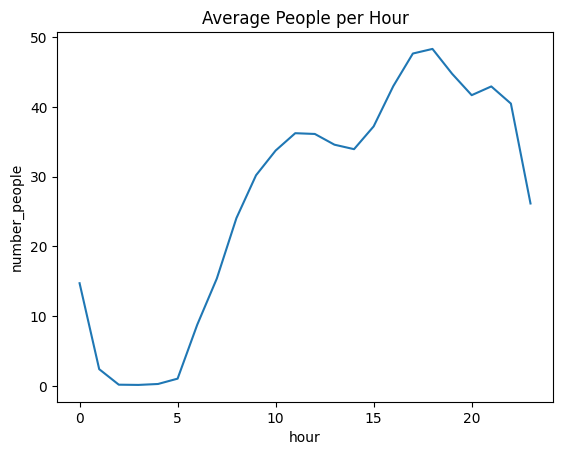

In [ ]:
sns.lineplot(data=df, x="hour", y="number_people", errorbar=None)
plt.title("Average People per Hour")
plt.show()

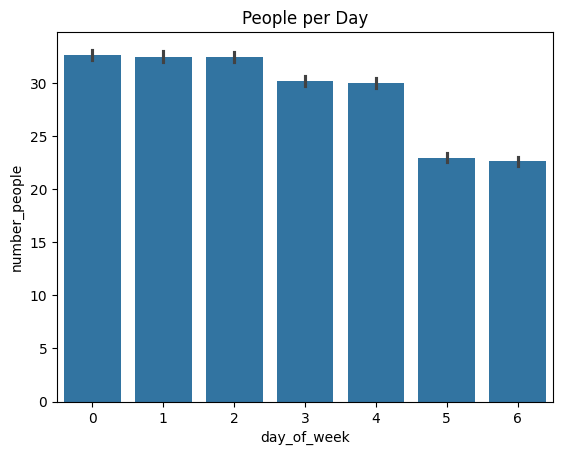

In [ ]:
sns.barplot(data=df, x="day_of_week", y="number_people")
plt.title("People per Day")
plt.show()

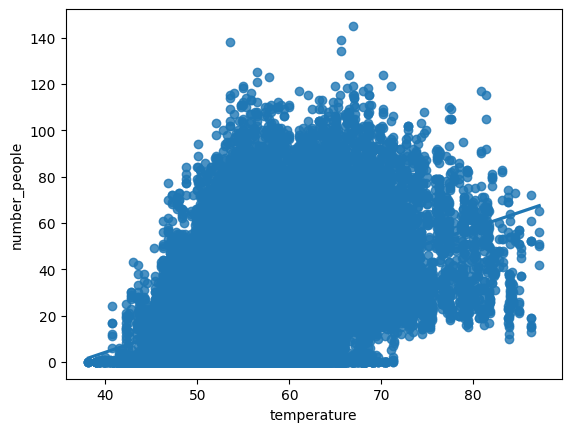

In [ ]:
sns.regplot(data=df, x="temperature", y="number_people")
plt.show()

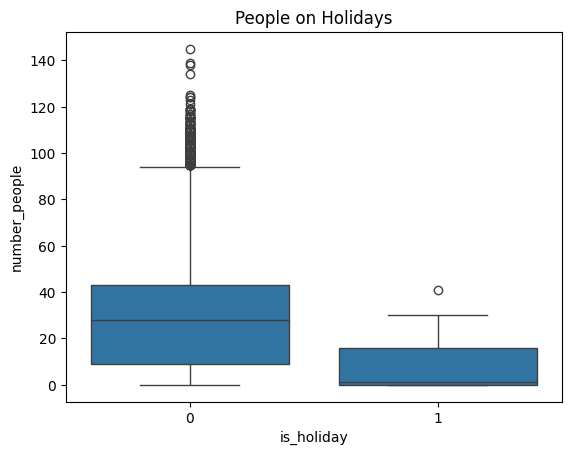

In [ ]:
sns.boxplot(data=df, x="is_holiday", y="number_people")
plt.title("People on Holidays")
plt.show()

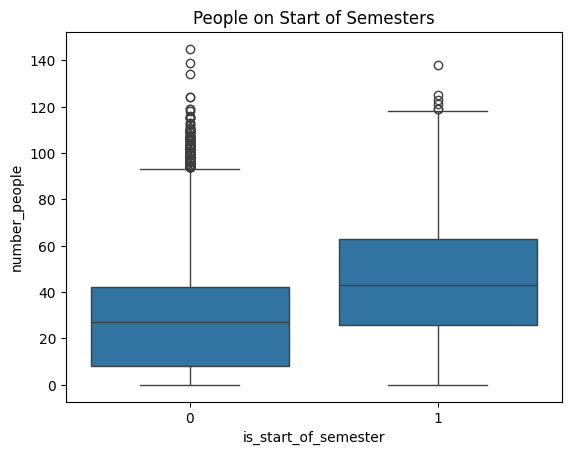

In [ ]:
sns.boxplot(data=df, x="is_start_of_semester", y="number_people")
plt.title("People on Start of Semesters")
plt.show()

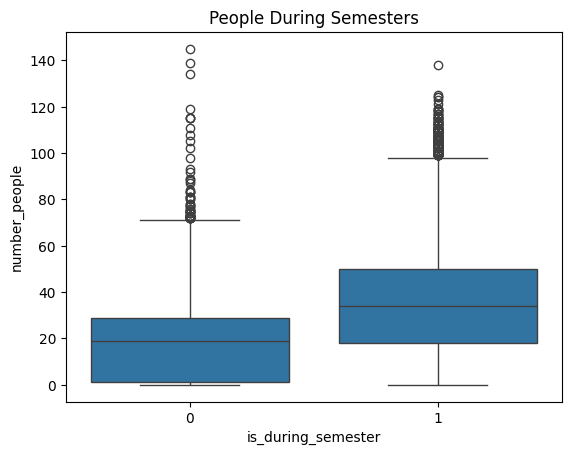

In [ ]:
sns.boxplot(data=df, x="is_during_semester", y="number_people")
plt.title("People During Semesters")
plt.show()

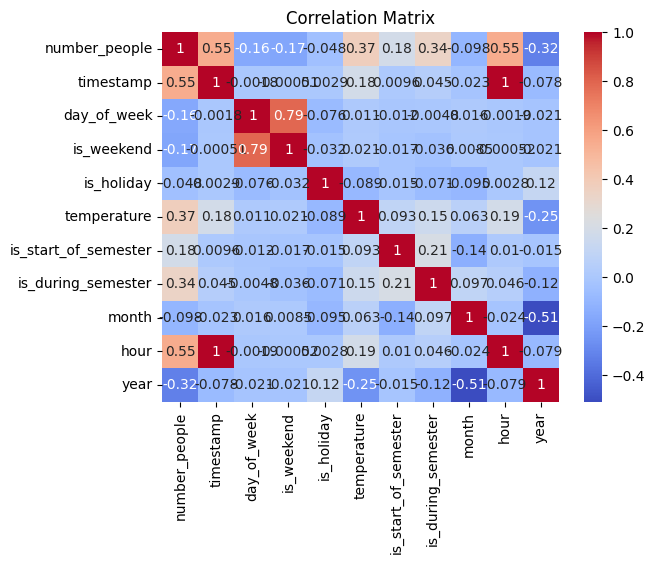

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm") # annot=True → Hücrelerin içinde sayılar görünür (örneğin 0.85, -0.32 gibi)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.corr()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
number_people,1.000000,0.550218,-0.162062,-0.173958,-0.048249,0.373327,0.182683,0.335350,-0.097854,0.552049,-0.322591
timestamp,0.550218,1.000000,-0.001793,-0.000509,0.002851,0.184849,0.009551,0.044676,-0.023221,0.999077,-0.077767
day_of_week,-0.162062,-0.001793,1.000000,0.791338,-0.075862,0.011169,-0.011782,-0.004824,0.015559,-0.001914,-0.021242
is_weekend,-0.173958,-0.000509,0.791338,1.000000,-0.031899,0.020673,-0.016646,-0.036127,0.008462,-0.000517,-0.021260
is_holiday,-0.048249,0.002851,-0.075862,-0.031899,1.000000,-0.088527,-0.014858,-0.070798,-0.094942,0.002843,0.121129
temperature,0.373327,0.184849,0.011169,0.020673,-0.088527,1.000000,0.093242,0.152476,0.063125,0.185121,-0.249638
is_start_of_semester,0.182683,0.009551,-0.011782,-0.016646,-0.014858,0.093242,1.000000,0.209862,-0.137160,0.010091,-0.015377
is_during_semester,0.335350,0.044676,-0.004824,-0.036127,-0.070798,0.152476,0.209862,1.000000,0.096556,0.045581,-0.124302
month,-0.097854,-0.023221,0.015559,0.008462,-0.094942,0.063125,-0.137160,0.096556,1.000000,-0.023624,-0.508552
hour,0.552049,0.999077,-0.001914,-0.000517,0.002843,0.185121,0.010091,0.045581,-0.023624,1.000000,-0.078816


In [ ]:
df.drop('timestamp', axis = 1, inplace=True) # chata sordu hangi colonu drop edeyim diye

In [ ]:
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


In [ ]:
#chat end

In [ ]:
#dependent & independent feature
X = df.drop('number_people', axis= 1)
y = df['number_people']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=15)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
#calculations
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [ ]:
#adding initialising steps for train them concurrently. We can add or remove them
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso": Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor"  : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor()
}

In [ ]:
for i in range(len(list(models))): # models sözlüğündeki eleman sayısı kadar (6 model) döngü çalışır. i değeri 0'dan 5'e kadar artar
    model = list(models.values())[i] #i=0 için: LinearRegression() seçilir ve eğitilir, i=1 için: Lasso() seçilir ve eğitilir
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train) #Eğitilen model ile eğitim seti için tahminler yapılır
    y_test_pred = model.predict(X_test)   #Aynı model ile test seti için tahminler yapılır

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred) #Eğitim seti için: MAE, RMSE, R2 skoru hesaplanır
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)      #Test seti için: MAE, RMSE, R2 skoru hesaplanır Overfitting (Aşırı Öğrenme) Kontrolü!!!

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("RMSE :", model_train_rmse)
    print("Mean Absolute Error :", model_train_mae)
    print("R2 Score :", model_train_r2)

    print("-----------------------------")

    print("Evaluation for Test Set")
    print("RMSE :", model_test_rmse)
    print("Mean Absolute Error :", model_test_mae)
    print("R2 Score :", model_test_r2)

    print("-----------------------------")
    print("\n")

LinearRegression()
Evaluation for Training Set
RMSE : 14.322500408269727
Mean Absolute Error : 10.733469936454322
R2 Score : 0.5999639521710998
-----------------------------
Evaluation for Test Set
RMSE : 14.45063290337055
Mean Absolute Error : 10.779752371029558
R2 Score : 0.5989271376662775
-----------------------------


Lasso()
Evaluation for Training Set
RMSE : 14.569122351126817
Mean Absolute Error : 10.945189874221992
R2 Score : 0.5860687429058037
-----------------------------
Evaluation for Test Set
RMSE : 14.703511215751082
Mean Absolute Error : 10.970594902476911
R2 Score : 0.5847671974050243
-----------------------------


Ridge()
Evaluation for Training Set
RMSE : 14.322500413912243
Mean Absolute Error : 10.733479178820698
R2 Score : 0.5999639518559021
-----------------------------
Evaluation for Test Set
RMSE : 14.450633329986024
Mean Absolute Error : 10.779759559023008
R2 Score : 0.5989271139851151
-----------------------------


KNeighborsRegressor()
Evaluation for Train